# SPX volatility surface: our own implied vol, raw

The 3D surface built from **our own** Black-76 solver (`engine.blackscholes.implied_vol`),
not CBOE's published `iv`. Raw scatter, nothing fitted and nothing connected: every dot is
one contract's implied vol, inverted from its own market mid.

- **IV source.** Ours (ADR 010). `cboe_iv` stays in `eda.ipynb`, where it validates the
  clean -> slice -> surface pipeline; it is not used here. A side-by-side of the two on the
  fitted surface is a later step (the fit it compares against now lives in `surface_svi.ipynb`).
- **Cleaning.** The same pipeline as the EDA: `bid/ask > 0` + `T > 0`, parity forward per
  expiry, OTM side only, one root per expiry (ADR 015), axis `m = ln(K/F)` (ADR 003 / 009 / 011).
- **Not fitted.** The dots are a ragged fan, not a surface. Filling it in (resample onto a
  regular `(m, T)` grid, fit SVI/SSVI, check no-arb) is done in `surface_svi.ipynb`; here
  nothing is joined by lines, because connecting across maturities would draw an
  interpolation this notebook has not done.
- **Data.** One pinned SPX snapshot off CBOE's delayed feed. The raw chain is gitignored
  (ADR 001), so the rendered outputs are the deliverable.

In [7]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from engine.data import load_chain, chain_to_frame, download_chain
from engine.filters import bidask_mask, expiry_mask
from engine.surface import forward_by_expiry, select_otm, blend_roots
from engine.blackscholes import implied_vol

# colorblind-safe palette (Wong), matching eda.ipynb
C_CALL, C_PUT = "#0173B2", "#DE8F05"
C_KEEP, C_DROP = "#029E73", "#BBBBBB"
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
# --- the one snapshot this analysis is built on (raw chain gitignored, ADR 001) ---
# To run on your own data: download_chain() to fetch+save a snapshot, then set PINNED to
# its date. load_chain reads disk only and raises FileNotFoundError if you don't have it.
PINNED = "2026-07-13"
RATE   = 0.04                                 # r, the only free input (ADR 003)

raw = load_chain(PINNED)
df  = chain_to_frame(raw)

ASOF_TS = df.attrs["asof"]                    # full quote timestamp, the provenance stamp
ASOF    = ASOF_TS.normalize()                 # midnight, for day counts downstream
SPOT    = df.attrs["spot"]                    # cash index level at the snapshot

print(f"SPX chain as of {ASOF_TS}  (CBOE delayed feed)")
print(f"{len(df):,} contracts | spot {SPOT:,.1f}")

SPX chain as of 2026-07-13 21:19:31  (CBOE delayed feed)
29,486 contracts | spot 7,515.3


In [9]:
# --- the clean pipeline, same as eda.ipynb, plus the root blend for the full surface ---

def build_clean(frame, r: float = RATE):
    """Raw chain -> clean OTM quotes on a moneyness axis (ADR 009/011).

    bid/ask>0 + T>0  ->  parity forward per expiry  ->  keep the OTM side  ->  moneyness
    m = ln(K/F). Adds columns F and m.
    """
    d = frame[bidask_mask(frame) & expiry_mask(frame)].copy()
    d["F"] = d["expiry"].map(forward_by_expiry(d, r))
    d = d.dropna(subset=["F"])
    d = d[select_otm(d)].copy()
    d["m"] = np.log(d["strike"] / d["F"])
    return d


# one root per expiry: SPXW <=60d, richest beyond (engine.surface.blend_roots, ADR 015).
# Shared with surface_svi.ipynb so the two notebooks can't drift on this choice.
CLEAN = blend_roots(build_clean(df))
CLEAN["days"] = (CLEAN["expiry"] - ASOF).dt.days

print(f"clean OTM quotes: {len(CLEAN):,} across {CLEAN['expiry'].nunique()} expiries")
print(f"maturities: {CLEAN['days'].min()}d to {CLEAN['days'].max()}d")

clean OTM quotes: 12,091 across 55 expiries
maturities: 1d to 1985d


## Inverting every clean quote

One safeguarded Newton solve per contract, vectorized: find the sigma whose Black-76 price
off the parity forward reproduces that contract's mid (ADR 010/014). A Newton step (using
`bs_vega`) sits inside a bracket that falls back to bisection wherever the step misbehaves,
so it reaches machine precision fast yet cannot diverge; the upper bound isn't hardcoded but
expands until it brackets the root.

The solver always returns *something*, so the solutions are screened rather than trusted.
Two ways a quote has no honest implied vol: a **mid below intrinsic**, which no sigma
reproduces, so the search collapses toward the lower bound; and a **mid at or above the
forward bound**, where no finite sigma matches, so the bracket expands out to its guard and
the result lands far above any real vol. Both are quote problems rather than solver
problems, since the round-trip test recovers a known sigma to ~1e-14 (ADR 014).

On this snapshot the screen catches **nothing** — every clean quote inverts to a plausible
vol. That is a statement about this snapshot, not a guarantee, and the screen stays as a
guard because the failure is known to occur: before `expiry_mask` existed, one expired
contract reached the solver and blew past any real vol (ADR 011). Whether the wide wings
also need the deferred spread-outlier filter is a question for the *fit*, where quote
scatter shows up as fit error — not for the inversion, which handles them here.

In [10]:
CLEAN["iv"] = implied_vol(
    CLEAN["mid"], CLEAN["F"], CLEAN["strike"], CLEAN["T"], CLEAN["type"], r=RATE
)

# screen the degenerate solves (see above): plausibility bounds on the result, not the
# solver's own bracket (which expands as needed).
IV_FLOOR, IV_CEIL = 0.01, 3.0                 # 1% and 300% vol: outside any real SPX quote
solved = CLEAN["iv"].between(IV_FLOOR, IV_CEIL)

n_lo, n_hi = int((CLEAN["iv"] < IV_FLOOR).sum()), int((CLEAN["iv"] > IV_CEIL).sum())
print(f"solved      {int(solved.sum()):,} / {len(CLEAN):,}  ({solved.mean():.1%})")
print(f"  collapsed {n_lo:,}  (mid at/below intrinsic)")
print(f"  pinned    {n_hi:,}  (mid at/above the bound)")

SURF = CLEAN[solved].copy()
print(f"\nIV percentiles (vol pts): "
      f"{(SURF['iv'].quantile([0.01, 0.25, 0.5, 0.75, 0.99]) * 100).round(1).to_dict()}")

solved      12,091 / 12,091  (100.0%)
  collapsed 0  (mid at/below intrinsic)
  pinned    0  (mid at/above the bound)

IV percentiles (vol pts): {0.01: 10.0, 0.25: 14.7, 0.5: 19.5, 0.75: 27.8, 0.99: 73.0}


## The surface, unfitted

Every solved contract as one dot: `m = ln(K/F)` against maturity, height is our implied vol.
Nothing is joined, so what you see is exactly what the market quoted and our solver
inverted.

Two things the raw dots make obvious, both of which the fit is meant to fix:

- **It is a fan, not a grid.** Near-dated expiries span a narrow moneyness range and
  far-dated ones a wide one, and no two expiries share a strike ladder. There is no `(m, T)`
  rectangle to interpolate on yet.
- **Maturity is crushed at the near end.** On a linear day axis the weeklies, where the smile
  actually moves, pile up against the origin while the LEAPS stretch out to 2031. A `sqrt(T)`
  or delta-band axis is the standard fix and is parked in `docs/STATE.md`.

`M_VIEW` below is a **view window**, not a filter: the deep wings carry the noisiest quotes
and would otherwise set the z-scale for everything. The count outside it is printed.

showing 11,456 of 12,091 solved quotes (635 outside |m| <= 0.6)


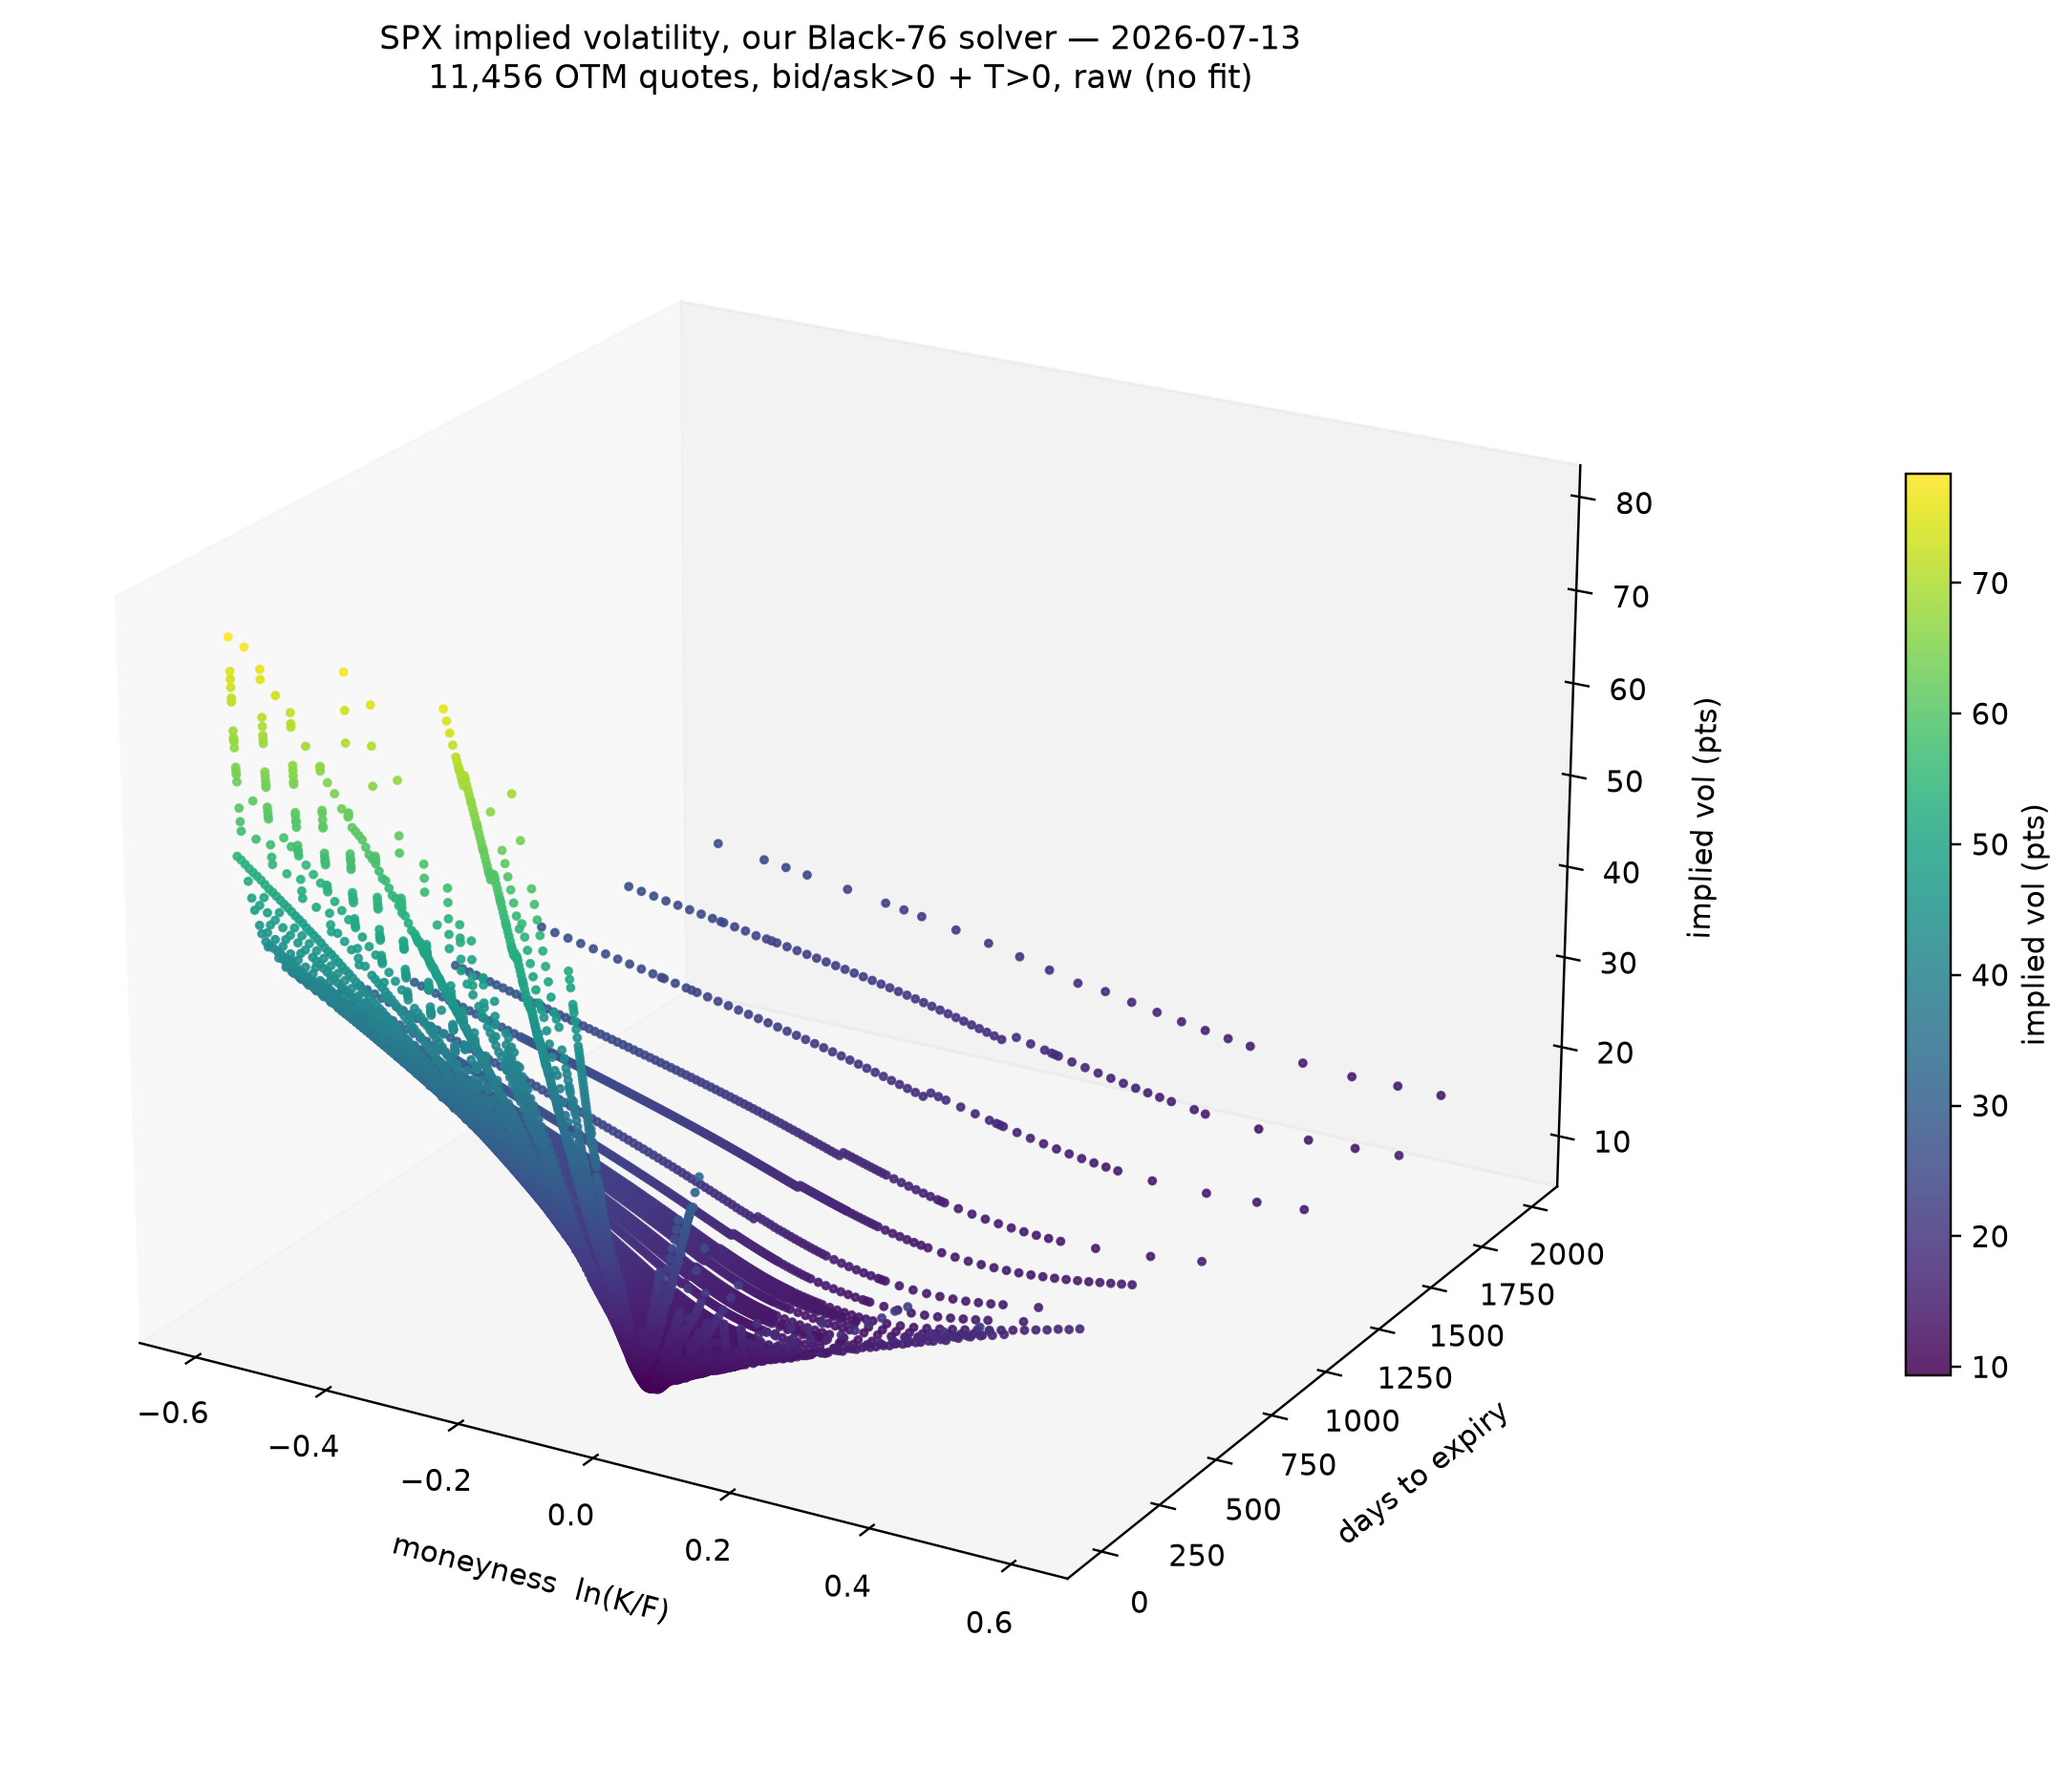

In [11]:
M_VIEW = 0.6                                  # plot window on ln(K/F); not a data filter
view = SURF[SURF["m"].abs() <= M_VIEW]
print(f"showing {len(view):,} of {len(SURF):,} solved quotes "
      f"({len(SURF) - len(view):,} outside |m| <= {M_VIEW})")

fig = plt.figure(figsize=(12, 8.5))
ax = fig.add_subplot(111, projection="3d")

p = ax.scatter(view["m"], view["days"], view["iv"] * 100,
               c=view["iv"] * 100, cmap="viridis", s=5, alpha=0.85, depthshade=False)

ax.set_xlabel("moneyness  ln(K/F)", labelpad=10)
ax.set_ylabel("days to expiry", labelpad=10)
ax.set_zlabel("implied vol (pts)", labelpad=8)
ax.set_title(f"SPX implied volatility, our Black-76 solver — {ASOF_TS:%Y-%m-%d}\n"
             f"{len(view):,} OTM quotes, bid/ask>0 + T>0, raw (no fit)", fontsize=11)
ax.view_init(elev=22, azim=-60)
ax.grid(False)
fig.colorbar(p, ax=ax, shrink=0.55, pad=0.10, label="implied vol (pts)")
plt.tight_layout()
plt.show()

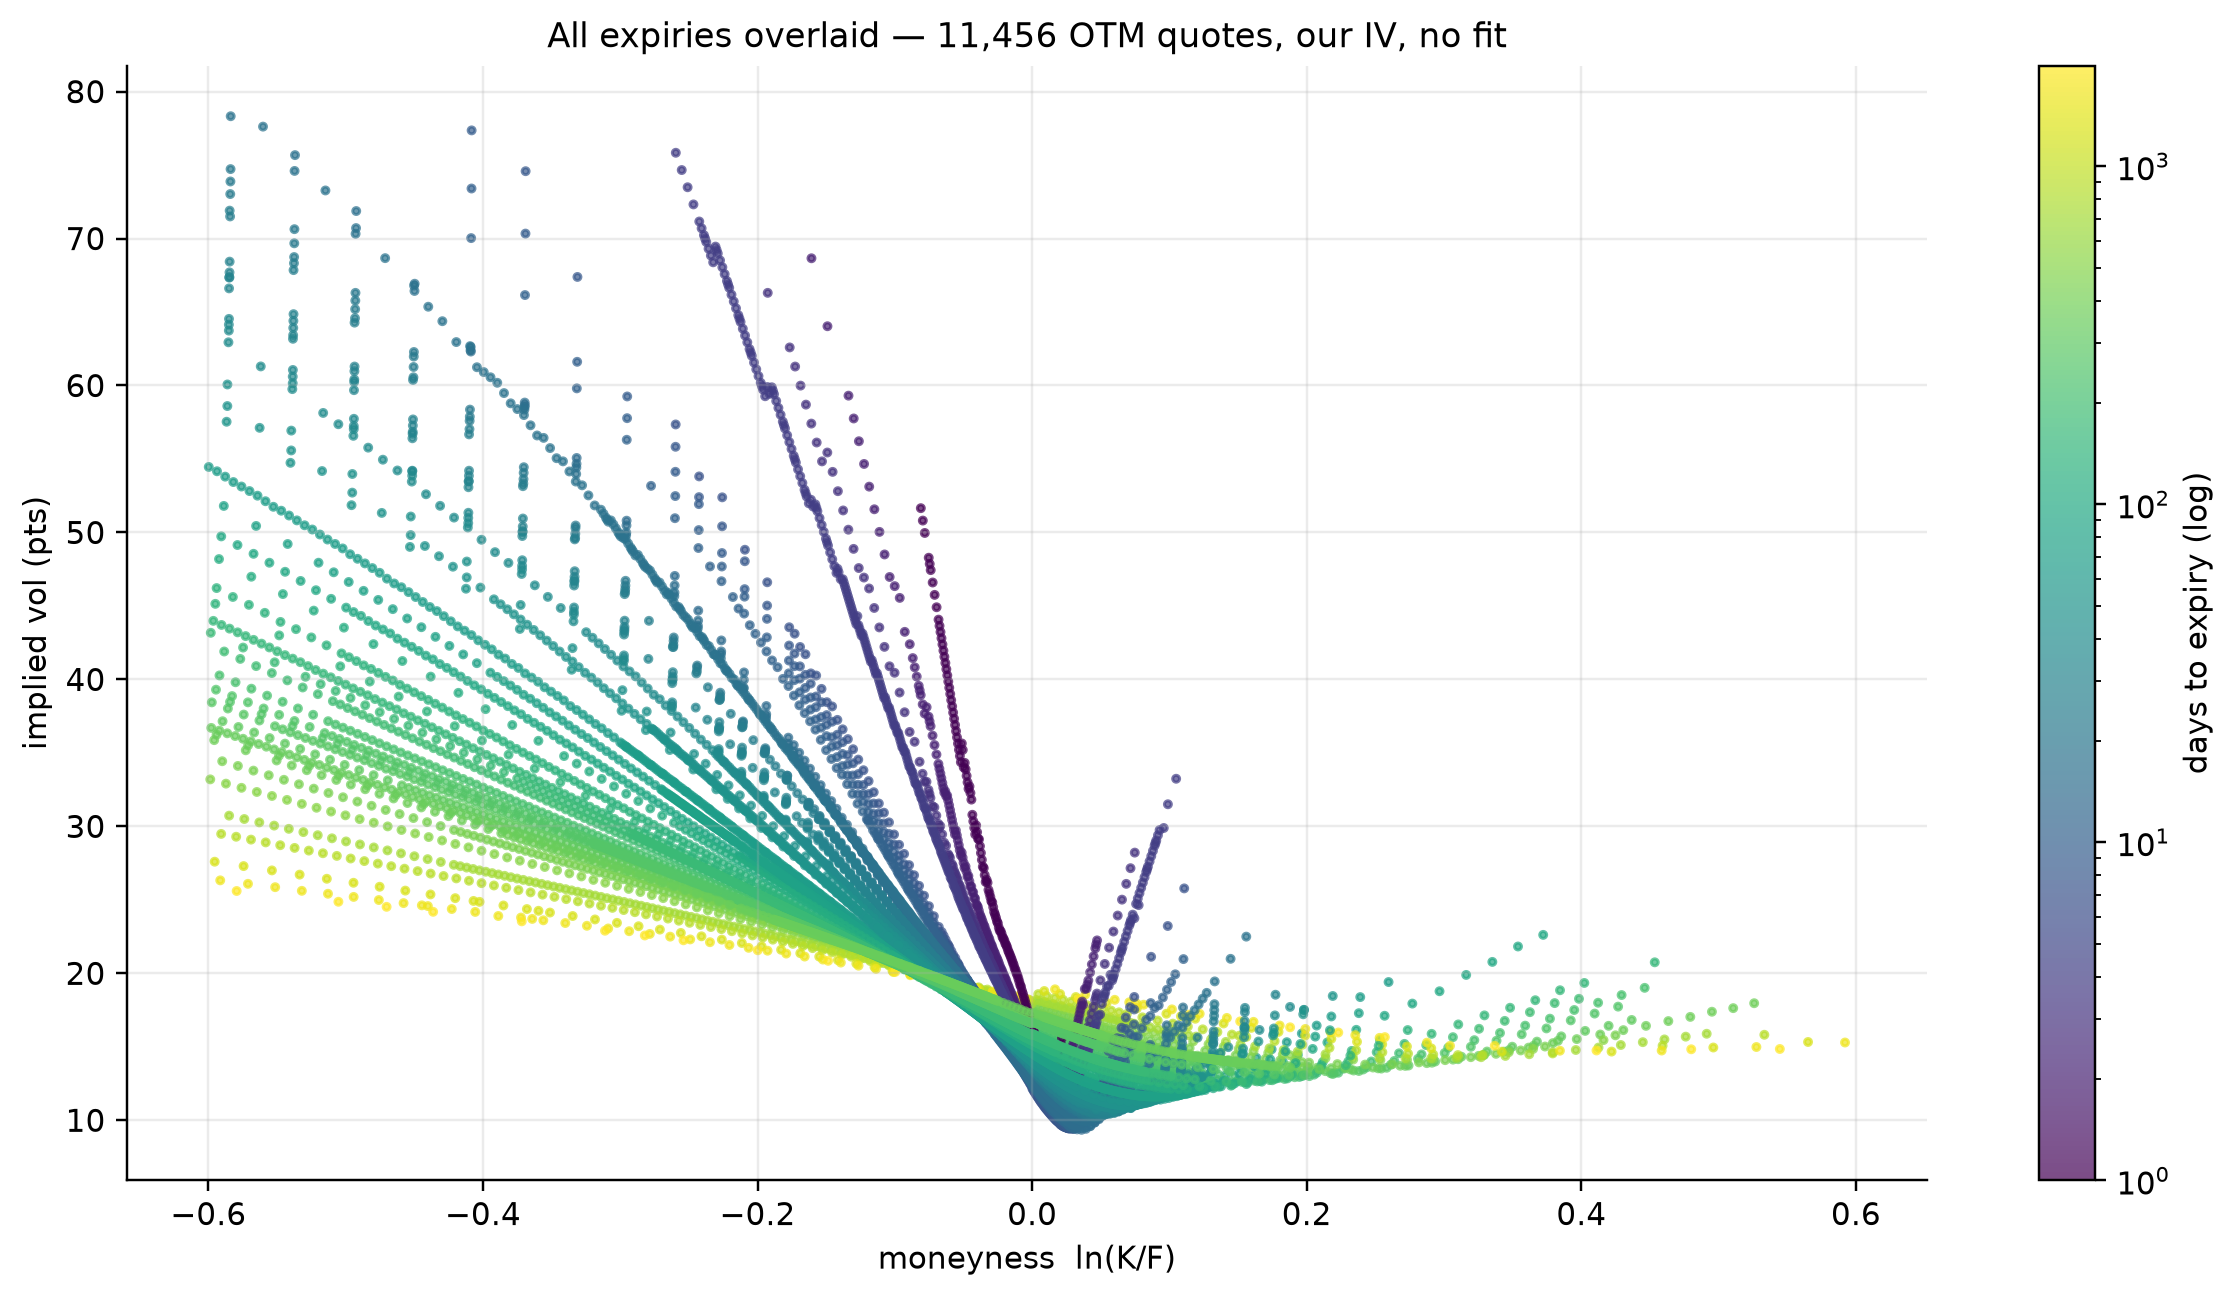

In [12]:
# same data, looking straight down the maturity axis: every expiry's smile at once.
# The fan structure and the near-term crush both read more clearly flat than in 3D.
fig, ax = plt.subplots(figsize=(11, 6))
s = ax.scatter(view["m"], view["iv"] * 100, c=view["days"], cmap="viridis",
               s=5, alpha=0.7, norm="log")
ax.set_xlabel("moneyness  ln(K/F)")
ax.set_ylabel("implied vol (pts)")
ax.set_title(f"All expiries overlaid — {len(view):,} OTM quotes, our IV, no fit", fontsize=11)
fig.colorbar(s, ax=ax, label="days to expiry (log)")
plt.tight_layout()
plt.show()

## Next

The SVI/SSVI fit that turns this fan into an arbitrage-checked surface is built in
`surface_svi.ipynb` (per-expiry SVI, global SSVI, butterfly + calendar checks). Still open:
a CBOE-vs-ours side-by-side on the fitted surface, and the median+MAD spread-outlier filter.